In [5]:
from pathlib import Path
import json, warnings
import numpy as np, pandas as pd, scipy.io as sio
from scipy import signal, stats
import matplotlib.pyplot as plt
from joblib import Parallel, delayed
from tqdm.auto import tqdm
import sys
sys.path.insert(0, str(Path.cwd().parent.parent))


warnings.filterwarnings("ignore")
plt.rcParams.update({"figure.dpi": 110, "axes.grid": True, "grid.alpha": .3})



ROOT      = Path("../data_paderborn")   # <-- folder containing K001, KA01, ... KB27
OUT       = Path("../data_paderborn/processed"); OUT.mkdir(parents=True, exist_ok=True)

FIG  = OUT / "figs"; FIG.mkdir(exist_ok=True)
N_JOBS = 8

# ---- documented facts (used for labels/PSD only, never to derive record length) ----
FAST_CHANNELS = ["vibration_1", "phase_current_1", "phase_current_2"]   # 64 kHz raster
SLOW_CHANNELS = ["force", "speed", "torque"]                            # 4 kHz raster
AUX_CHANNELS  = ["temp_2_bearing_module"]                               # ~1 Hz raster
ALL_CHANNELS  = FAST_CHANNELS + SLOW_CHANNELS + AUX_CHANNELS
FS_FAST, FS_SLOW = 64_000, 4_000

CLASS_OF   = {"K0": 0, "KA": 1, "KI": 2, "KB": 3}
CLASS_NAME = {0: "healthy", 1: "outer_ring", 2: "inner_ring", 3: "combined"}

ARTIFICIAL = {"KA01","KA03","KA05","KA06","KA07","KA08","KA09",
              "KI01","KI03","KI05","KI07","KI08"}
REAL       = {"KA04","KA15","KA16","KA22","KA30","KB23","KB24","KB27",
              "KI04","KI14","KI16","KI17","KI18","KI21"}

# 6203 geometry -> order multiples of shaft rate (for spectrum markers)
BPFO_ORDER, BPFI_ORDER = 3.053, 4.947

In [6]:
def parse(p: Path):
    b = p.parent.name
    n, m, f, brg, trial = p.stem.split("_")
    origin = "healthy" if b.startswith("K0") else \
             "artificial" if b in ARTIFICIAL else "real" if b in REAL else "unknown"
    return dict(path=str(p), bearing=b, prefix=b[:2], label=CLASS_OF[b[:2]],
                label_name=CLASS_NAME[CLASS_OF[b[:2]]], origin=origin,
                cond=f"{n}_{m}_{f}", speed_set=n, torque_set=m, force_set=f,
                trial=int(trial), size_mb=round(p.stat().st_size / 2**20, 2))

files = pd.DataFrame([parse(p) for p in sorted(ROOT.rglob("*.mat"))])
files.to_parquet(OUT / "inventory.parquet", index=False)

print(f"{len(files)} files | {files.bearing.nunique()} bearings | "
      f"{files.size_mb.sum()/1024:.1f} GB on disk")
display(files.head())

2560 files | 32 bearings | 20.8 GB on disk


,path,bearing,prefix,label,label_name,origin,cond,speed_set,torque_set,force_set,trial,size_mb
0,..\data_paderborn\K001\N09_M07_F10_K001_1.mat,K001,K0,0,healthy,healthy,N09_M07_F10,N09,M07,F10,1,8.34
1,..\data_paderborn\K001\N09_M07_F10_K001_10.mat,K001,K0,0,healthy,healthy,N09_M07_F10,N09,M07,F10,10,8.33
2,..\data_paderborn\K001\N09_M07_F10_K001_11.mat,K001,K0,0,healthy,healthy,N09_M07_F10,N09,M07,F10,11,8.31
3,..\data_paderborn\K001\N09_M07_F10_K001_12.mat,K001,K0,0,healthy,healthy,N09_M07_F10,N09,M07,F10,12,8.31
4,..\data_paderborn\K001\N09_M07_F10_K001_13.mat,K001,K0,0,healthy,healthy,N09_M07_F10,N09,M07,F10,13,8.31


In [7]:
print("files per bearing:", files.groupby('bearing').size().unique())
print("N09 / N15 per bearing:",
      files.assign(g=files.speed_set).pivot_table(index="bearing", columns="g",
      aggfunc="size").agg(["min","max"]).to_dict())

display(files.pivot_table(index="bearing", columns="cond", aggfunc="size", fill_value=0))
display(files.groupby(["label_name","origin"]).agg(files=("path","size"),
        bearings=("bearing","nunique")))

files per bearing: [80]
N09 / N15 per bearing: {'N09': {'min': 20, 'max': 20}, 'N15': {'min': 60, 'max': 60}}


cond,N09_M07_F10,N15_M01_F10,N15_M07_F04,N15_M07_F10
bearing,,,,
K001,20,20,20,20
K002,20,20,20,20
K003,20,20,20,20
K004,20,20,20,20
K005,20,20,20,20
K006,20,20,20,20
KA01,20,20,20,20
KA03,20,20,20,20
KA04,20,20,20,20


files  bearings
label_name origin                     
combined   real          240         3
healthy    healthy       480         6
inner_ring artificial    400         5
           real          480         6
outer_ring artificial    560         7
           real          400         5

In [8]:
def _txt(e, field):
    v = np.asarray(getattr(e, field, ""))
    return str(v.ravel()[0]).strip() if v.size else ""

def load_root(path):
    mat = sio.loadmat(path, struct_as_record=False, squeeze_me=True)
    return next(v for k, v in mat.items() if not k.startswith("__"))

def read_pdb_mat(path, channels=None, n_keep=None, with_time=False):
    """Signals from root.Y only. Time axes are taken verbatim from root.X via XIndex."""
    root = load_root(path)
    axes = np.atleast_1d(getattr(root, "X", []))
    sig, tim = {}, {}
    for e in np.atleast_1d(root.Y):
        name = _txt(e, "Name")                       # '' for unnamed/placeholder entries
        if not name or (channels is not None and name not in channels):
            continue
        x = np.asarray(getattr(e, "Data", []), dtype=np.float32).ravel()
        if x.size == 0:
            continue
        if n_keep is not None:
            x = x[:n_keep]
        sig[name] = x
        if with_time:
            k = int(np.ravel(getattr(e, "XIndex", 1))[0])
            t = np.asarray(getattr(axes[k-1], "Data", []), dtype=np.float64).ravel() \
                if 1 <= k <= axes.size else np.empty(0)
            tim[name] = t[:x.size]
    return (sig, tim) if with_time else sig

# ---------- informational structure dump for one file ----------
demo = files.query("bearing=='KA04' and cond=='N15_M07_F10' and trial==1").iloc[0]
root = load_root(demo.path)
print(demo.path, "\ntop-level fields:", root._fieldnames)

info = []
for i, e in enumerate(np.atleast_1d(root.Y)):
    k = int(np.ravel(getattr(e, "XIndex", 1))[0])
    ax = np.atleast_1d(root.X)[k-1]
    t  = np.asarray(getattr(ax, "Data", []), dtype=np.float64).ravel()
    d  = np.asarray(getattr(e, "Data", [])).ravel()
    info.append(dict(i=i, name=_txt(e, "Name") or "<EMPTY>", unit=_txt(e, "Unit"),
                     device=_txt(e, "Device"), raster=np.ravel(getattr(e,"Raster",np.nan))[0],
                     x_index=k, n_samples=d.size, dtype=str(d.dtype),
                     t_first=t[0] if t.size else None, t_last=t[-1] if t.size else None))
display(pd.DataFrame(info))          # informational: 7 rows, all named

ax_info = [dict(axis=j+1, name=_txt(x, "Name") or "<EMPTY>",
                n=np.asarray(getattr(x,"Data",[])).size,
                t_first=np.asarray(getattr(x,"Data",[])).ravel()[:1],
                t_last=np.asarray(getattr(x,"Data",[])).ravel()[-1:])
           for j, x in enumerate(np.atleast_1d(root.X))]
display(pd.DataFrame(ax_info))       # the shared time bases (this was the phantom "Unknown")

..\data_paderborn\KA04\N15_M07_F10_KA04_1.mat 
top-level fields: ['Info', 'X', 'Y', 'Description']


,i,name,unit,device,raster,x_index,n_samples,dtype,t_first,t_last
0,0,force,,Platform,Mech_4kHz,1,16001,float64,-0.000109,3.999839
1,1,phase_current_1,,Platform,HostService,2,256004,float64,0.000000,3.999995
2,2,phase_current_2,,Platform,HostService,2,256004,float64,0.000000,3.999995
3,3,speed,,Platform,Mech_4kHz,1,16001,float64,-0.000109,3.999839
4,4,temp_2_bearing_module,,Platform,Temp_1Hz,3,5,float64,-0.003326,3.996683
5,5,torque,,Platform,Mech_4kHz,1,16001,float64,-0.000109,3.999839
6,6,vibration_1,,Platform,HostService,2,256004,float64,0.000000,3.999995


,axis,name,n,t_first,t_last
0,1,<EMPTY>,16001,[-0.00010949815200482146],[3.9998391745892428]
1,2,<EMPTY>,256004,[0.0],[3.999995295001281]
2,3,<EMPTY>,5,[-0.003326434094302717],[3.996682975903135]


In [9]:
def signature(path):
    try:
        sig, tim = read_pdb_mat(path, with_time=True)
        r = {"path": path, "channels": "|".join(sorted(sig)), "error": ""}
        for c, x in sig.items():
            r[f"n_{c}"] = x.size
            t = tim.get(c, np.empty(0))
            r[f"tlast_{c}"] = t[-1] if t.size else np.nan
        return r
    except Exception as e:
        return {"path": path, "channels": "", "error": f"{type(e).__name__}: {e}"}

cen = pd.DataFrame(Parallel(N_JOBS)(delayed(signature)(p)
                   for p in tqdm(files.path, desc="census")))
cen.to_parquet(OUT / "census.parquet", index=False)

print("errors:", (cen.error != "").sum())
display(cen.channels.value_counts().to_frame("files"))
display(cen.filter(like="n_").agg(["min", "max", "nunique"]).T)
display(cen.filter(like="tlast_").agg(["min", "max"]).T)   # informational: read from X

N_KEEP = int(cen[[f"n_{c}" for c in FAST_CHANNELS]].min().min())
print("N_KEEP (min observed length of 64 kHz channels) =", N_KEEP)

census:   0%|          | 0/2560 [00:00<?, ?it/s]

errors: 1


,files
channels,
force|phase_current_1|phase_current_2|speed|temp_2_bearing_module|torque|vibration_1,2559
,1


,min,max,nunique
n_force,16000.000000,18691.000000,11.0
n_phase_current_1,249940.000000,299038.000000,394.0
n_phase_current_2,249940.000000,299038.000000,394.0
n_speed,16000.000000,18691.000000,11.0
n_temp_2_bearing_module,4.000000,5.000000,2.0
n_torque,16000.000000,18691.000000,11.0
n_vibration_1,249940.000000,299038.000000,394.0
tlast_vibration_1,3.905296,4.672454,420.0


,min,max
tlast_force,3.999751,4.672391
tlast_phase_current_1,3.905296,4.672454
tlast_phase_current_2,3.905296,4.672454
tlast_speed,3.999751,4.672391
tlast_temp_2_bearing_module,3.000009,3.999162
tlast_torque,3.999751,4.672391
tlast_vibration_1,3.905296,4.672454


N_KEEP (min observed length of 64 kHz channels) = 249940


In [13]:
def feats(row):
    try:
        sig = read_pdb_mat(row.path, channels=ALL_CHANNELS, n_keep=N_KEEP)
    except Exception as e:
        # If the file fails to load, return basic info and the error message
        return dict(path=row.path, bearing=row.bearing, label=row.label,
                    label_name=row.label_name, origin=row.origin, cond=row.cond,
                    trial=row.trial, error=repr(e))

    d = dict(path=row.path, bearing=row.bearing, label=row.label,
             label_name=row.label_name, origin=row.origin, cond=row.cond,
             trial=row.trial, error="")

    for c in FAST_CHANNELS:
        if c not in sig: continue  # Skip if channel is missing
        x = sig[c].astype(np.float64); a = np.abs(x)
        rms = np.sqrt((x**2).mean())
        d |= {f"{c}_mean": x.mean(), f"{c}_std": x.std(), f"{c}_rms": rms,
              f"{c}_ptp": np.ptp(x), f"{c}_skew": stats.skew(x),
              f"{c}_kurt": stats.kurtosis(x, fisher=False),
              f"{c}_crest": a.max()/rms if rms > 0 else 0,
              f"{c}_shape": rms/a.mean() if a.mean() > 0 else 0,
              f"{c}_impulse": a.max()/a.mean() if a.mean() > 0 else 0,
              f"{c}_clear": a.max()/(np.mean(np.sqrt(a))**2) if a.mean() > 0 else 0,
              f"{c}_zcr": np.mean(np.diff(np.signbit(x)) != 0)}

    if "vibration_1" in sig:
        f, P = signal.welch(sig["vibration_1"], FS_FAST, nperseg=8192)
        tot = P.sum() + 1e-12
        for lo, hi in [(0,1e3),(1e3,3e3),(3e3,6e3),(6e3,1e4),(1e4,2e4),(2e4,3.2e4)]:
            d[f"vib_bandE_{int(lo)}_{int(hi)}"] = P[(f>=lo)&(f<hi)].sum()/tot
        d["vib_specentropy"] = stats.entropy(P/tot)

    d |= {"speed_rpm": np.median(sig.get("speed", [np.nan])),
          "torque_nm": np.median(sig.get("torque", [np.nan])),
          "force_n": np.median(sig.get("force", [np.nan])),
          "temp_c": float(np.mean(sig.get("temp_2_bearing_module", [np.nan])))}
    return d

F = pd.DataFrame(Parallel(N_JOBS)(delayed(feats)(r)
                 for r in tqdm(files.itertuples(), total=len(files), desc="features")))
F.to_parquet(OUT / "file_features.parquet", index=False)
display(F.groupby("label_name")[["vibration_1_rms","vibration_1_kurt",
        "vibration_1_crest","speed_rpm","torque_nm","temp_c"]].agg(["mean","std"]).round(3))

features:   0%|          | 0/2560 [00:00<?, ?it/s]

vibration_1_rms        vibration_1_kurt        vibration_1_crest  \
                      mean    std             mean    std              mean   
label_name                                                                    
combined             0.516  0.290            7.215  3.221             9.225   
healthy              0.277  0.102           14.629  7.859            12.543   
inner_ring           0.287  0.125           10.801  8.843            11.170   
outer_ring           0.287  0.133           10.357  7.526            10.603   

                  speed_rpm          torque_nm         temp_c         
              std      mean      std      mean    std    mean    std  
label_name                                                            
combined    2.425  1349.647  260.293     1.088  0.273  48.785  3.509  
healthy     3.251  1349.633  260.016     1.090  0.272  46.558  2.595  
inner_ring  4.118  1349.630  259.901     1.087  0.274  45.417  6.463  
outer_ring  3.806  1349.464  259.975     1.087  0.278  48.175  3.115

speed_rpm                         torque_nm                    \
                 mean   std      min      max      mean   std   min   max   
cond                                                                        
N09_M07_F10    899.73  0.19   898.90   900.34      1.23  0.03  0.70  1.31   
N15_M01_F10   1499.62  0.23  1498.69  1501.55      0.61  0.04  0.45  0.70   
N15_M07_F04   1499.58  0.24  1498.08  1500.54      1.25  0.03  1.17  1.32   
N15_M07_F10   1499.59  0.21  1498.35  1500.73      1.26  0.03  1.17  1.34   

             force_n                         temp_c                      
                mean    std     min      max   mean   std    min    max  
cond                                                                     
N09_M07_F10  1032.50  41.21  956.25  1117.69  46.75  4.43  28.54  54.83  
N15_M01_F10  1049.64  38.75  970.90  1120.13  45.99  4.52  27.14  52.56  
N15_M07_F04   418.40  43.10  341.33   549.15  46.87  5.00  25.01  54.40  
N15_M07_F10  1032.03  35.76  968.77  1125.02  48.31  4.54  29.59  58.50

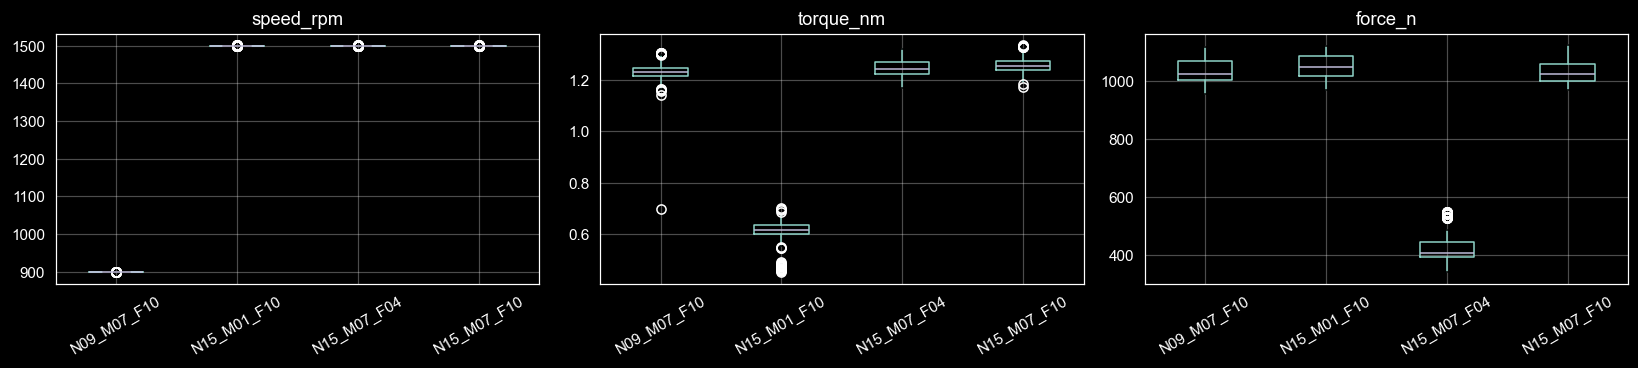

In [14]:
display(F.groupby("cond")[["speed_rpm","torque_nm","force_n","temp_c"]]
         .agg(["mean","std","min","max"]).round(2))

fig, ax = plt.subplots(1, 3, figsize=(15, 3.6))
for a, c in zip(ax, ["speed_rpm", "torque_nm", "force_n"]):
    F.boxplot(column=c, by="cond", ax=a, rot=30); a.set_title(c); a.set_xlabel("")
plt.suptitle(""); plt.tight_layout(); plt.savefig(FIG/"conditions.png"); plt.show()

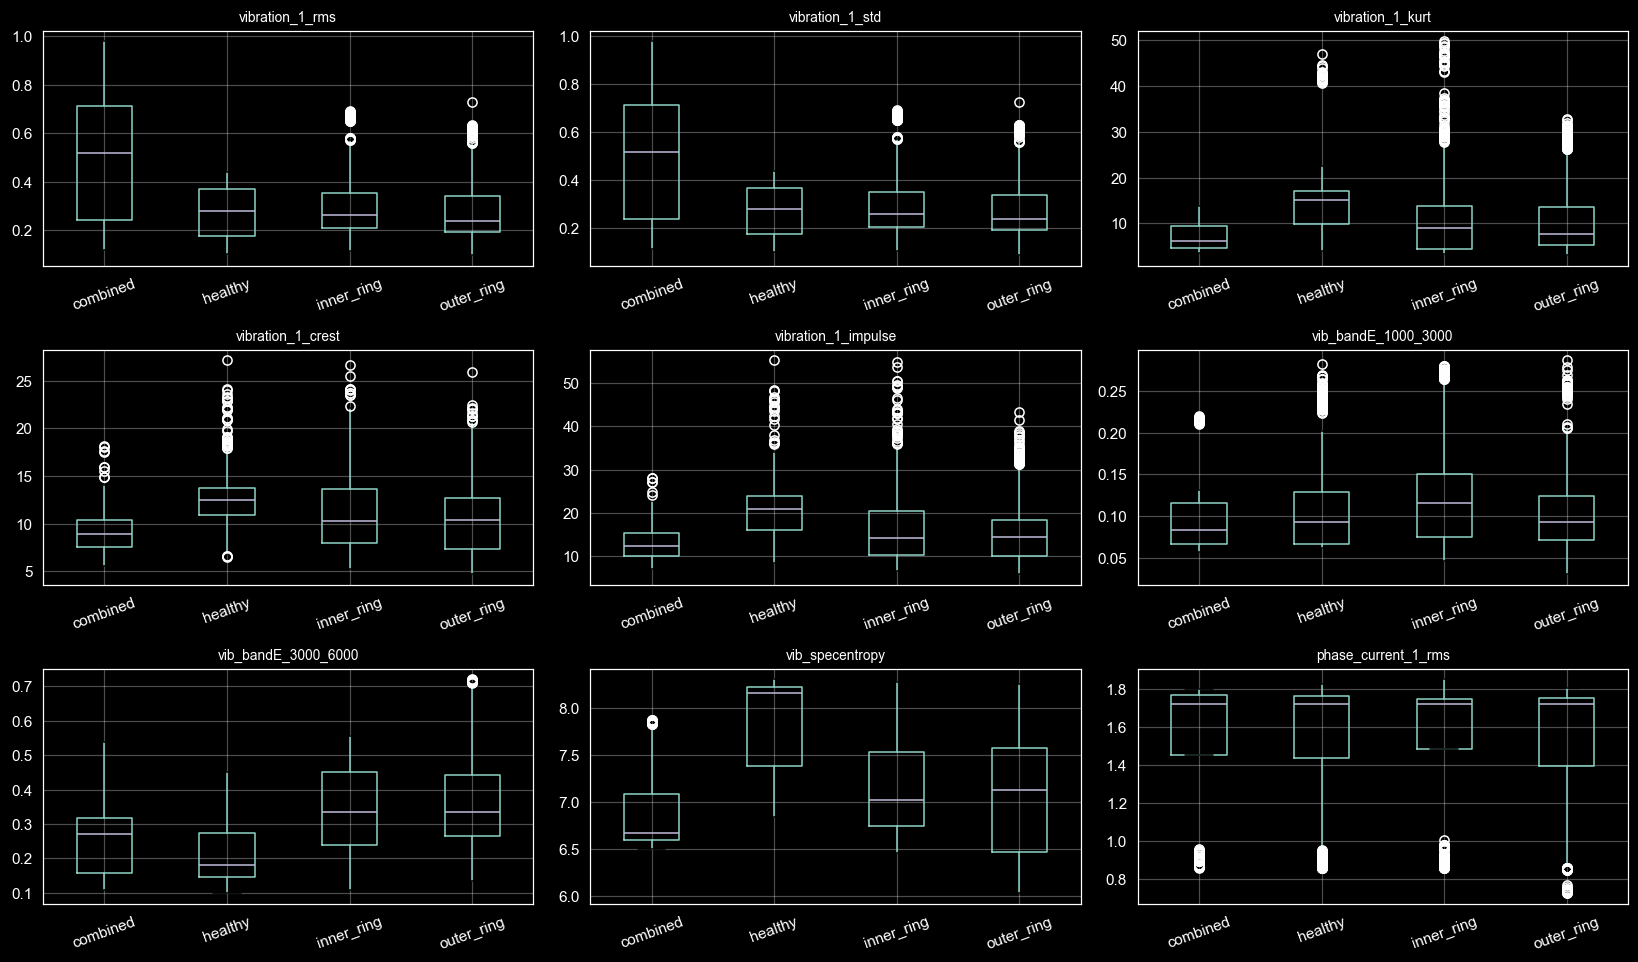

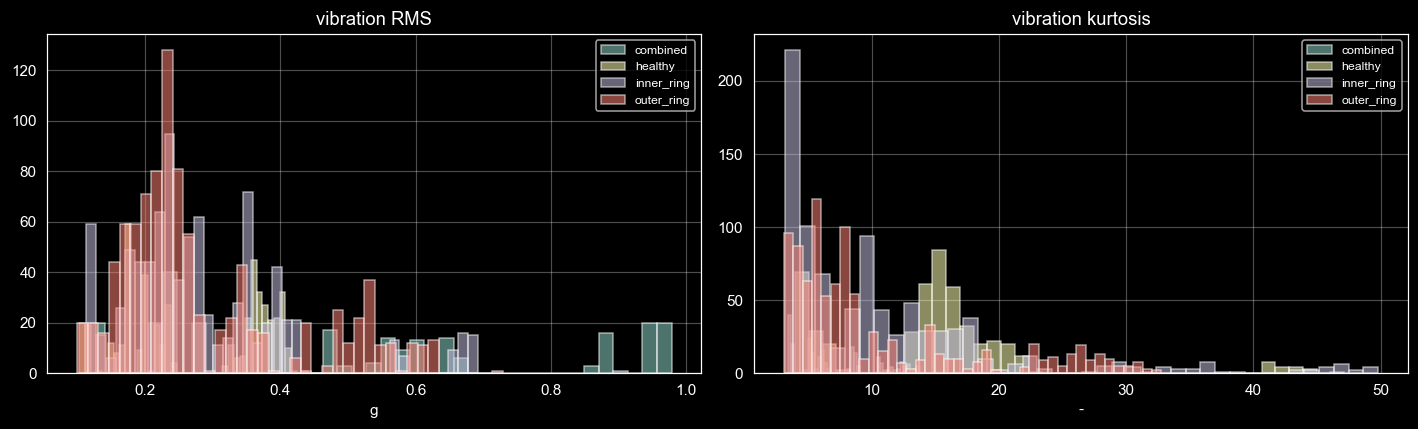

In [15]:
cols = ["vibration_1_rms","vibration_1_std","vibration_1_kurt","vibration_1_crest",
        "vibration_1_impulse","vib_bandE_1000_3000","vib_bandE_3000_6000",
        "vib_specentropy","phase_current_1_rms"]
fig, ax = plt.subplots(3, 3, figsize=(15, 9))
for a, c in zip(ax.ravel(), cols):
    F.boxplot(column=c, by="label_name", ax=a, rot=20); a.set_title(c, fontsize=9); a.set_xlabel("")
plt.suptitle(""); plt.tight_layout(); plt.savefig(FIG/"feature_dists.png"); plt.show()

fig, ax = plt.subplots(1, 2, figsize=(13, 4))
for k, (g, d) in enumerate(F.groupby("label_name")):
    ax[0].hist(d.vibration_1_rms, bins=40, alpha=.55, label=g)
    ax[1].hist(d.vibration_1_kurt, bins=40, alpha=.55, label=g)
ax[0].set(title="vibration RMS", xlabel="g"); ax[1].set(title="vibration kurtosis", xlabel="-")
[a.legend(fontsize=8) for a in ax]; plt.tight_layout(); plt.show()

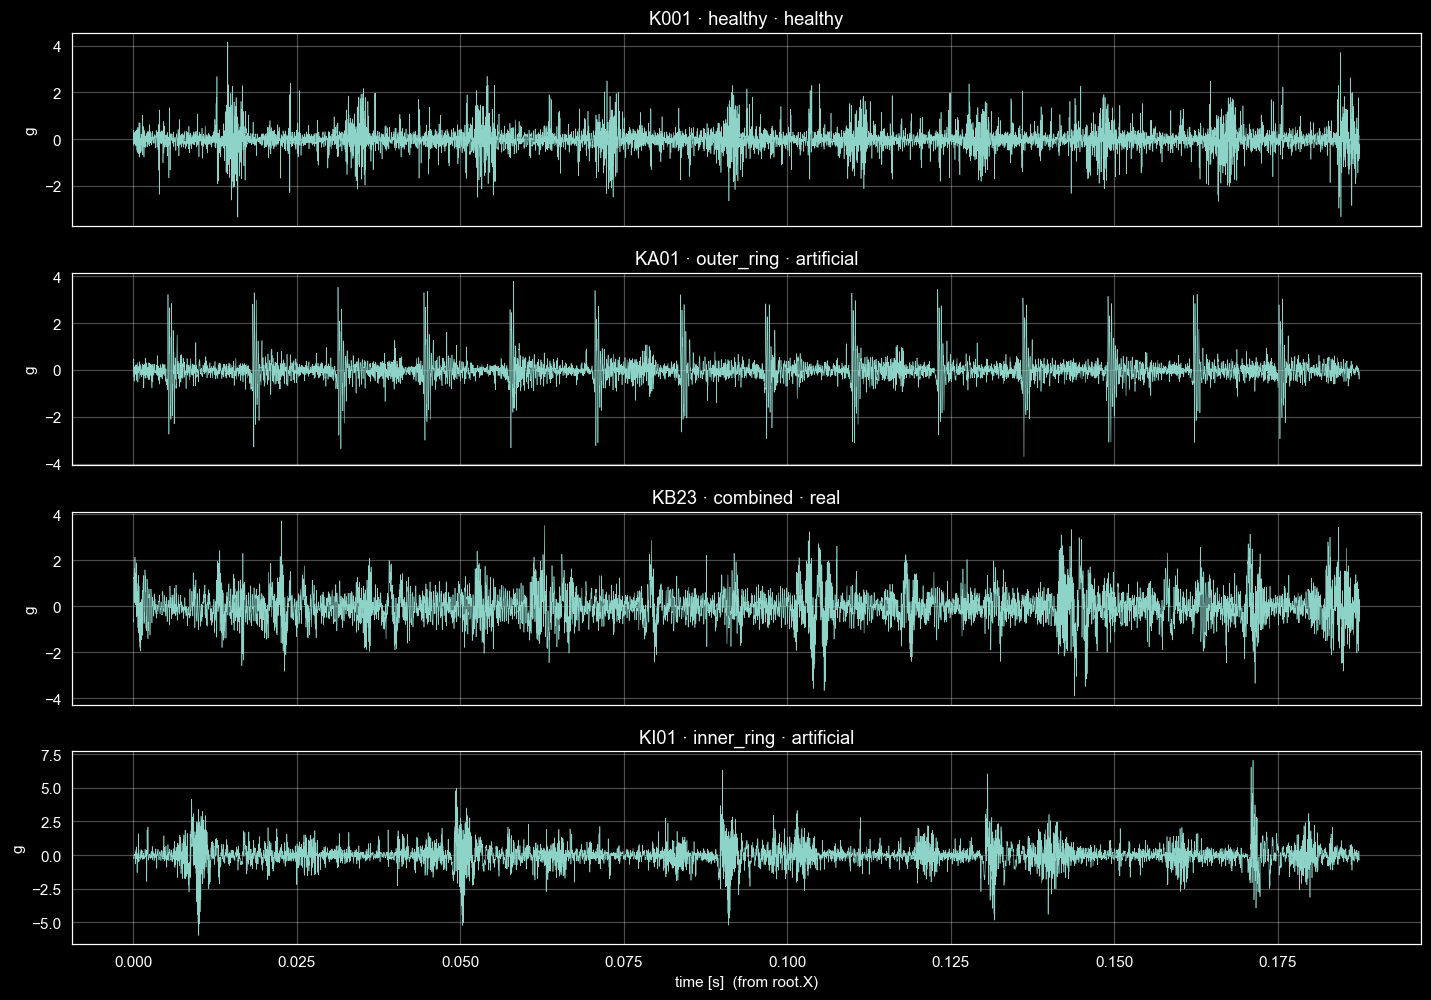

In [16]:
picks = files.query("cond=='N15_M07_F10' and trial==1").groupby("label_name").head(1)
fig, ax = plt.subplots(len(picks), 1, figsize=(13, 2.3*len(picks)), sharex=True)
for a, r in zip(np.atleast_1d(ax), picks.itertuples()):
    sig, tim = read_pdb_mat(r.path, channels=["vibration_1"], with_time=True)
    x, t = sig["vibration_1"], tim["vibration_1"]
    m = slice(0, 12_000)
    a.plot(t[m], x[m], lw=.4)
    a.set(ylabel="g", title=f"{r.bearing} · {r.label_name} · {r.origin}")
np.atleast_1d(ax)[-1].set_xlabel("time [s]  (from root.X)")
plt.tight_layout(); plt.savefig(FIG/"waveforms.png"); plt.show()

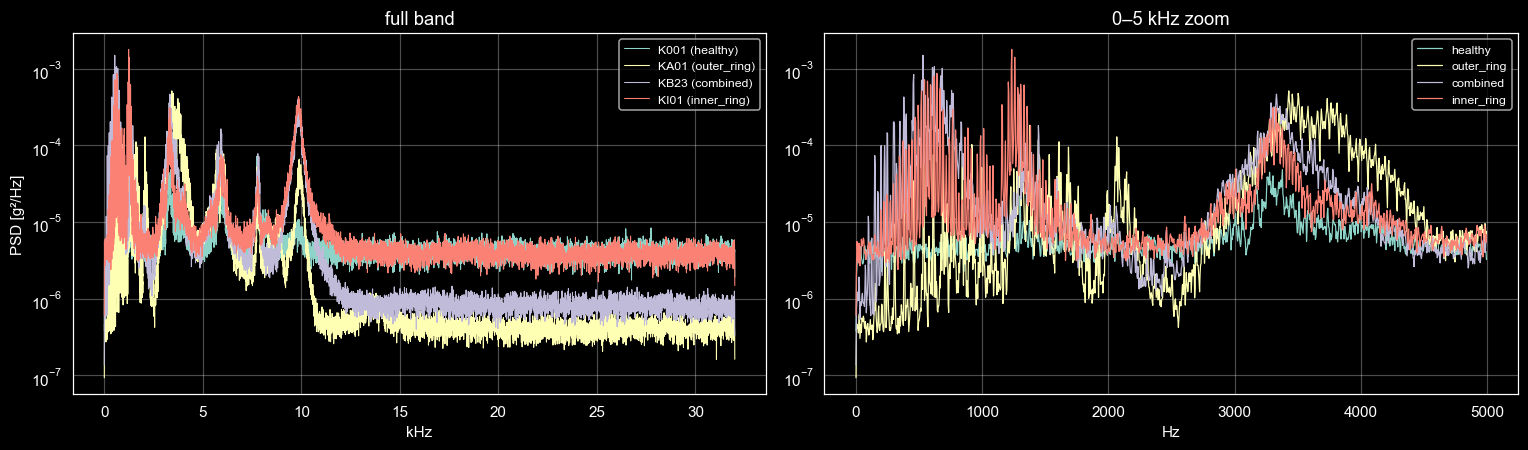

In [17]:
fig, ax = plt.subplots(1, 2, figsize=(14, 4.2))
for r in picks.itertuples():
    x = read_pdb_mat(r.path, channels=["vibration_1"], n_keep=N_KEEP)["vibration_1"]
    f, P = signal.welch(x, FS_FAST, nperseg=16384)
    ax[0].semilogy(f/1000, P, lw=.7, label=f"{r.bearing} ({r.label_name})")
    ax[1].semilogy(f[f<5000], P[f<5000], lw=.8, label=r.label_name)
ax[0].set(xlabel="kHz", ylabel="PSD [g²/Hz]", title="full band")
ax[1].set(xlabel="Hz", title="0–5 kHz zoom")
[a.legend(fontsize=8) for a in ax]; plt.tight_layout(); plt.savefig(FIG/"psd.png"); plt.show()

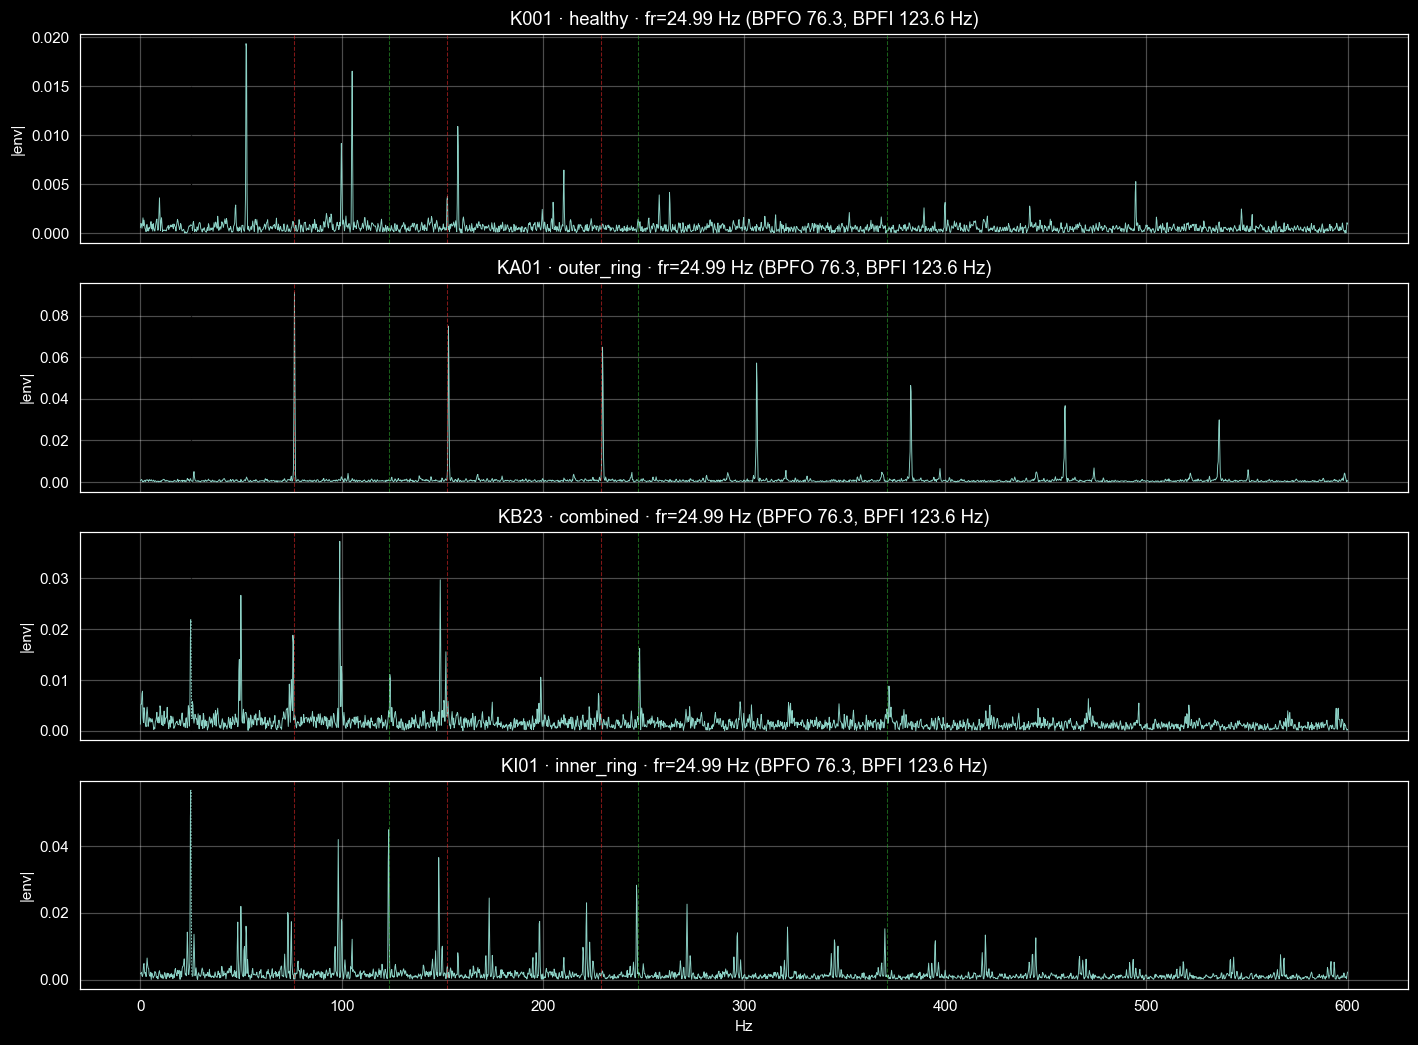

In [18]:
def env_spectrum(x, fs, band=(2000, 12000)):
    b, a = signal.butter(4, np.array(band)/(fs/2), "bandpass")
    env = np.abs(signal.hilbert(signal.filtfilt(b, a, x)))
    env -= env.mean()
    w = signal.get_window("hann", env.size)
    A = np.abs(np.fft.rfft(env*w)) / env.size
    return np.fft.rfftfreq(env.size, 1/fs), A

fig, ax = plt.subplots(len(picks), 1, figsize=(13, 2.4*len(picks)), sharex=True)
for a, r in zip(np.atleast_1d(ax), picks.itertuples()):
    sig = read_pdb_mat(r.path, channels=["vibration_1", "speed"], n_keep=N_KEEP)
    fr  = np.median(sig["speed"]) / 60.0
    f, A = env_spectrum(sig["vibration_1"], FS_FAST)
    m = f < 600
    a.plot(f[m], A[m], lw=.6)
    for lbl, o, col in [("BPFO", BPFO_ORDER, "tab:red"), ("BPFI", BPFI_ORDER, "tab:green")]:
        for k in (1, 2, 3):
            a.axvline(o*fr*k, color=col, ls="--", lw=.7, alpha=.6)
    a.axvline(fr, color="k", ls=":", lw=.8)
    a.set(ylabel="|env|", title=f"{r.bearing} · {r.label_name} · fr={fr:.2f} Hz "
                                f"(BPFO {BPFO_ORDER*fr:.1f}, BPFI {BPFI_ORDER*fr:.1f} Hz)")
np.atleast_1d(ax)[-1].set_xlabel("Hz")
plt.tight_layout(); plt.savefig(FIG/"envelope_spectra.png"); plt.show()

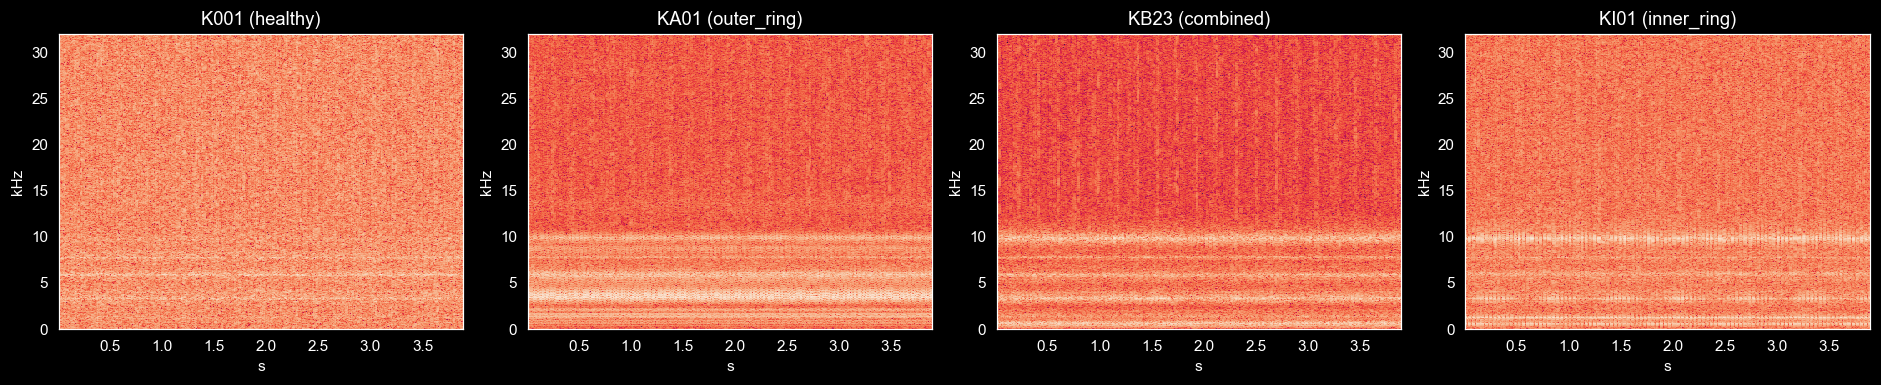

In [19]:
fig, ax = plt.subplots(1, len(picks), figsize=(4.3*len(picks), 3.6))
for a, r in zip(np.atleast_1d(ax), picks.itertuples()):
    x = read_pdb_mat(r.path, channels=["vibration_1"], n_keep=N_KEEP)["vibration_1"]
    f, t, S = signal.spectrogram(x, FS_FAST, nperseg=2048, noverlap=1536)
    a.pcolormesh(t, f/1000, 10*np.log10(S + 1e-14), shading="auto")
    a.set(title=f"{r.bearing} ({r.label_name})", xlabel="s", ylabel="kHz")
plt.tight_layout(); plt.savefig(FIG/"spectrograms.png"); plt.show()

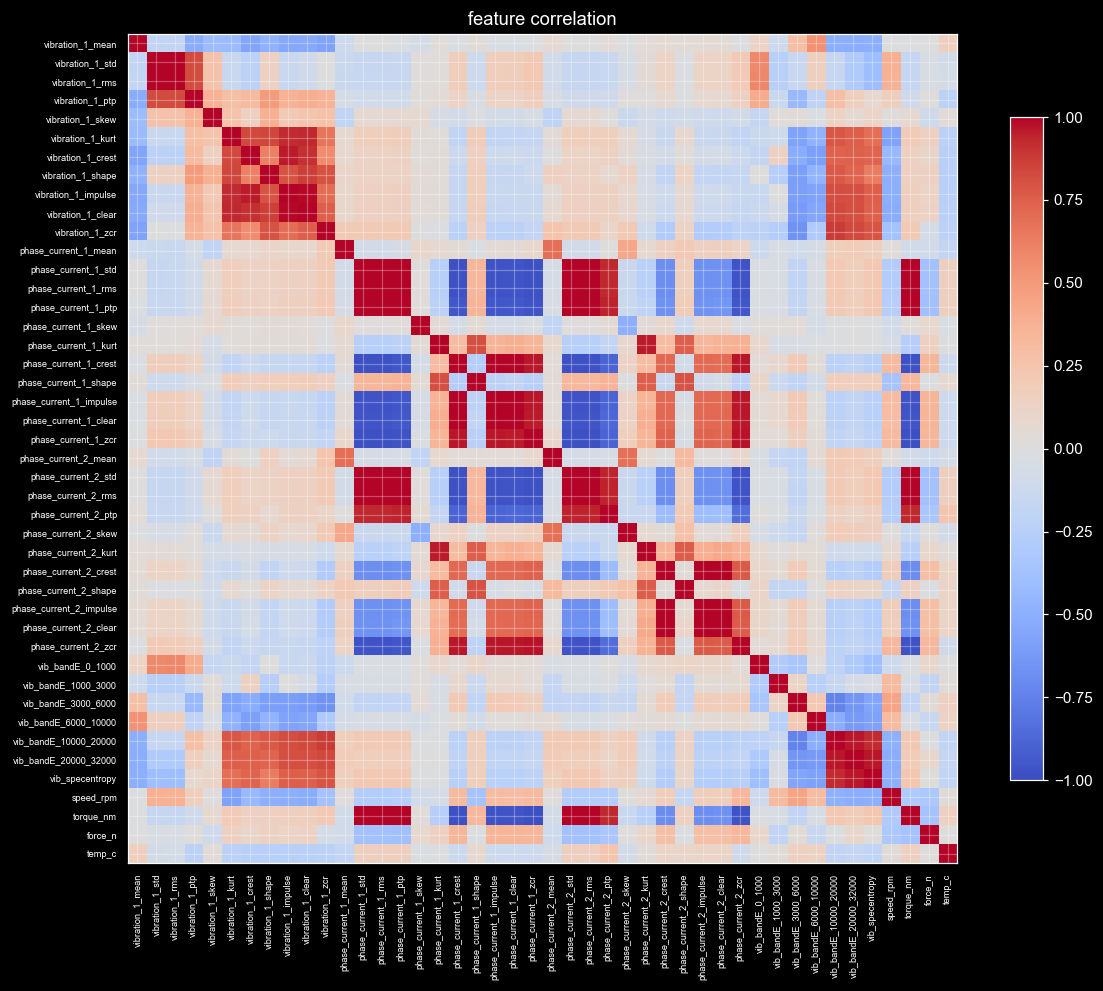

|r| > 0.95 pairs:


,,r
phase_current_1_std,phase_current_1_rms,0.999999
phase_current_2_std,phase_current_2_rms,0.999967
phase_current_1_std,phase_current_2_std,0.999942
phase_current_1_rms,phase_current_2_std,0.999941
vibration_1_std,vibration_1_rms,0.999931
phase_current_1_std,phase_current_2_rms,0.999924
phase_current_1_rms,phase_current_2_rms,0.999922
phase_current_2_impulse,phase_current_2_clear,0.999321
phase_current_2_crest,phase_current_2_impulse,0.999143
phase_current_1_impulse,phase_current_1_clear,0.998912


In [20]:
num = F.select_dtypes("number").drop(columns=["label","trial"], errors="ignore")
C = num.corr()
fig, ax = plt.subplots(figsize=(11, 9))
im = ax.imshow(C, cmap="coolwarm", vmin=-1, vmax=1)
ax.set_xticks(range(len(C))); ax.set_xticklabels(C.columns, rotation=90, fontsize=6)
ax.set_yticks(range(len(C))); ax.set_yticklabels(C.columns, fontsize=6)
plt.colorbar(im, shrink=.8); plt.title("feature correlation"); plt.tight_layout()
plt.savefig(FIG/"corr.png"); plt.show()

print("|r| > 0.95 pairs:")
u = C.where(np.triu(np.ones(C.shape), 1).astype(bool)).stack()
display(u[u.abs() > .95].sort_values(key=abs, ascending=False).to_frame("r").head(20))

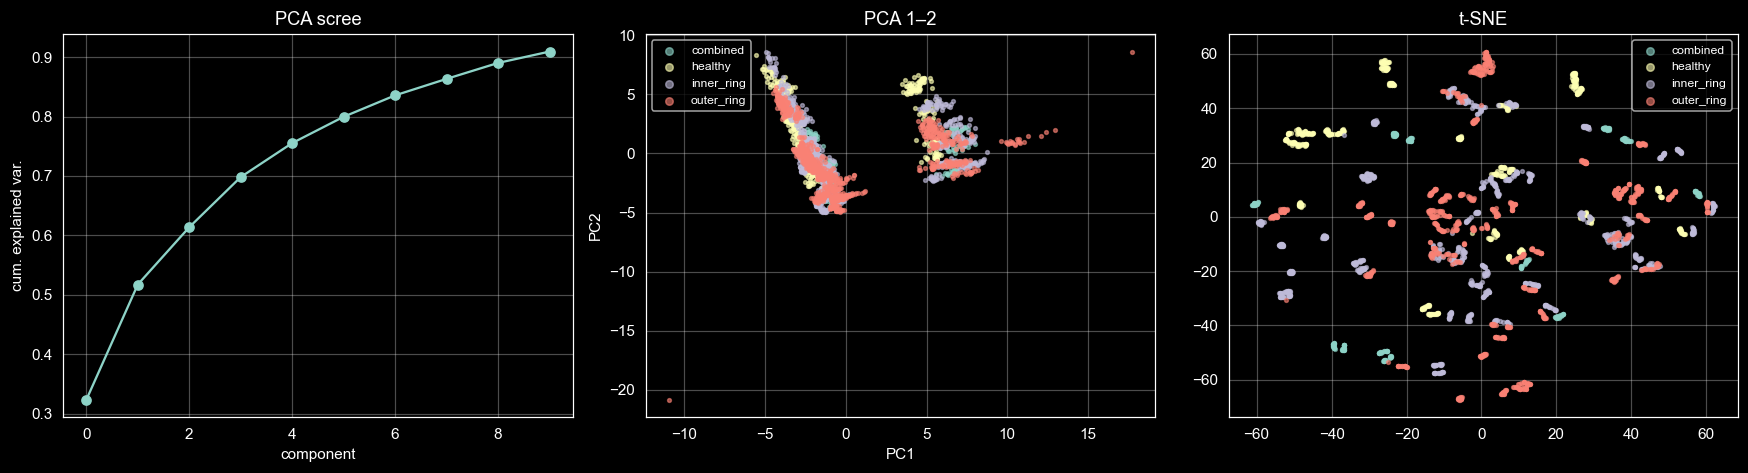

In [21]:
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE

X = StandardScaler().fit_transform(num.fillna(0).values)
pca = PCA(n_components=10).fit(X); Z = pca.transform(X)
ts  = TSNE(n_components=2, perplexity=30, init="pca", random_state=0).fit_transform(Z)

fig, ax = plt.subplots(1, 3, figsize=(16, 4.4))
ax[0].plot(np.cumsum(pca.explained_variance_ratio_), "o-")
ax[0].set(xlabel="component", ylabel="cum. explained var.", title="PCA scree")
for g, d in F.assign(p1=Z[:,0], p2=Z[:,1], t1=ts[:,0], t2=ts[:,1]).groupby("label_name"):
    ax[1].scatter(d.p1, d.p2, s=6, alpha=.6, label=g)
    ax[2].scatter(d.t1, d.t2, s=6, alpha=.6, label=g)
ax[1].set(title="PCA 1–2", xlabel="PC1", ylabel="PC2"); ax[2].set(title="t-SNE")
[a.legend(fontsize=8, markerscale=2) for a in ax[1:]]
plt.tight_layout(); plt.savefig(FIG/"pca_tsne.png"); plt.show()

json.dump({"n_keep": N_KEEP, "fast_channels": FAST_CHANNELS,
           "fs_fast": FS_FAST, "fs_slow": FS_SLOW, "n_files": len(files)},
          open(OUT/"eda_summary.json","w"), indent=2)

In [22]:
%%writefile pdb_io.py
import numpy as np, scipy.io as sio

FAST_CHANNELS = ["vibration_1", "phase_current_1", "phase_current_2"]
SLOW_CHANNELS = ["force", "speed", "torque"]
AUX_CHANNELS  = ["temp_2_bearing_module"]

def _txt(e, field):
    v = np.asarray(getattr(e, field, ""))
    return str(v.ravel()[0]).strip() if v.size else ""

def load_root(path):
    mat = sio.loadmat(path, struct_as_record=False, squeeze_me=True)
    return next(v for k, v in mat.items() if not k.startswith("__"))

def read_pdb_mat(path, channels=None, n_keep=None, with_time=False):
    root = load_root(path)
    axes = np.atleast_1d(getattr(root, "X", []))
    sig, tim = {}, {}
    for e in np.atleast_1d(root.Y):
        name = _txt(e, "Name")
        if not name or (channels is not None and name not in channels):
            continue
        x = np.asarray(getattr(e, "Data", []), dtype=np.float32).ravel()
        if x.size == 0:
            continue
        if n_keep is not None:
            x = x[:n_keep]
        sig[name] = x
        if with_time:
            k = int(np.ravel(getattr(e, "XIndex", 1))[0])
            t = np.asarray(getattr(axes[k-1], "Data", []), dtype=np.float64).ravel() \
                if 1 <= k <= axes.size else np.empty(0)
            tim[name] = t[:x.size]
    return (sig, tim) if with_time else sig

Overwriting pdb_io.py
